In [40]:
import requests

url_train = "https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/train.csv"
response = requests.get(url_train)
with open("titanic_data.csv", "wb") as file:
    file.write(response.content)

url_test = "https://raw.githubusercontent.com/dsindy/kaggle-titanic/master/data/test.csv"
response = requests.get(url_test)
with open("titanic_test.csv", "wb") as file:
    file.write(response.content)

## Import Dependencies

In [41]:
# Import the necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split

In [42]:
import seaborn as sns

## Read CSV File

In [43]:
# Read the following csv file
# 1. "titanic_data.csv" as labelled_dataset
# 2. "titanic_test.csv" as non_labelled_dataset

labelled_dataset = pd.read_csv('titanic_data.csv', delimiter=',') 
non_labelled_dataset = pd.read_csv('titanic_test.csv', delimiter=',')

In [44]:
labelled_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Explore the data

In [45]:
# Inspect the shape of the labelled_dataset and non_labelled_dataset
print('Labelled dataset shape:', labelled_dataset.shape)
print('Non-labelled dataset shape:', non_labelled_dataset.shape)

Labelled dataset shape: (891, 12)
Non-labelled dataset shape: (418, 11)


In [46]:
# Check the first 5 rows of labelled_dataset
labelled_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [47]:
# Check the first 5 rows of non_labelled_dataset
non_labelled_dataset.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [48]:
# Check information about labelled_dataset
labelled_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [49]:
# Check information of non_labelled_dataset
non_labelled_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [50]:
# Check how many missing values are there in labelled_dataset
labelled_dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [51]:
# Check how many missing values are there in non_labelled_dataset
non_labelled_dataset.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## Data Cleaning

In [52]:
# Drop column 'Cabin' from both data
labelled_dataset = labelled_dataset.drop('Cabin', axis=1, errors='ignore')
non_labelled_dataset = non_labelled_dataset.drop('Cabin', axis=1, errors='ignore')

In [53]:
# Fill in missing age for both dataset
mean_age_miss = labelled_dataset[labelled_dataset["Name"].str.contains('Miss.', na=False)]['Age'].mean().round()
mean_age_mrs = labelled_dataset[labelled_dataset["Name"].str.contains('Mrs.', na=False)]['Age'].mean().round()
mean_age_mr = labelled_dataset[labelled_dataset["Name"].str.contains('Mr.', na=False)]['Age'].mean().round()
mean_age_master = labelled_dataset[labelled_dataset["Name"].str.contains('Master.', na=False)]['Age'].mean().round()

In [54]:
def fill_age(name_age):

  name = name_age[0]
  age = name_age[1]
  if pd.isnull(age):
      if 'Mr.' in name:
          return mean_age_mr
      if 'Mrs.' in name:
          return mean_age_mrs
      if 'Miss.' in name:
          return mean_age_miss
      if 'Master.' in name:
          return mean_age_master
      if 'Dr.' in name:
          return mean_age_master
      if 'Ms.' in name:
          return mean_age_miss
  else:
      return age

In [55]:
labelled_dataset['Age'] = labelled_dataset[['Name', 'Age']].apply(fill_age,axis=1)
non_labelled_dataset['Age'] = non_labelled_dataset[['Name', 'Age']].apply(fill_age,axis=1)

C:\Users\benlo\AppData\Local\Temp\ipykernel_34156\1189350541.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  name = name_age[0]
C:\Users\benlo\AppData\Local\Temp\ipykernel_34156\1189350541.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = name_age[1]
C:\Users\benlo\AppData\Local\Temp\ipykernel_34156\1189350541.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  name = name_age[0]
C:\Users\benlo\AppData\Local\Temp\ipykern

In [56]:
# Delete missing data from 'Fare' and 'Embarked' column in both dataset
labelled_dataset = labelled_dataset.dropna(subset=['Fare', 'Embarked'])
non_labelled_dataset = non_labelled_dataset.dropna(subset=['Fare', 'Embarked'])

In [57]:
# Check missing values in labelled_dataset
labelled_dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [58]:
# Check missing values in non_labelled_dataset
non_labelled_dataset.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Data Preprocessing

In [59]:
# Encode the columns 'Sex' and 'Embarked' of the dataset
features_to_be_encoded = ['Sex', 'Embarked']

# Import and declare label encoder as le
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# For each feature stated in features_to_be_encoded,
# 1. Fit le with the respective feature column in labelled_dataset
# 2. Encode the respective column using le
for feature in features_to_be_encoded:
    labelled_dataset[feature] = le.fit_transform(labelled_dataset[feature])
    non_labelled_dataset[feature] = le.transform(non_labelled_dataset[feature])

In [60]:
# Print first 5 rows of labelled_dataset
labelled_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [61]:
# Scale the values for each selected columns stored in features_to_be_scaled
features_to_be_scaled = ['Pclass','Sex','Age','SibSp','Parch','Embarked']

# Import and declare a MinMaxScaler as scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fit scaler with the selected columns
scaler.fit(labelled_dataset[features_to_be_scaled])

# Encode the selected columns from both dataset
labelled_dataset[features_to_be_scaled] = scaler.transform(labelled_dataset[features_to_be_scaled])
non_labelled_dataset[features_to_be_scaled] = scaler.transform(non_labelled_dataset[features_to_be_scaled])

In [62]:
# Print first 5 rows of labelled_dataset
labelled_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,1.0,"Braund, Mr. Owen Harris",1.0,0.271174,0.125,0.0,A/5 21171,7.2500,1.0
1,2,1,0.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,0.472229,0.125,0.0,PC 17599,71.2833,0.0
2,3,1,1.0,"Heikkinen, Miss. Laina",0.0,0.321438,0.000,0.0,STON/O2. 3101282,7.9250,1.0
3,4,1,0.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,0.434531,0.125,0.0,113803,53.1000,1.0
4,5,0,1.0,"Allen, Mr. William Henry",1.0,0.434531,0.000,0.0,373450,8.0500,1.0


## Data Splitting

In [63]:
x = labelled_dataset[features_to_be_scaled]
y = labelled_dataset['Survived']

In [64]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split x and y into x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Classification Model

Model Building & Testing

In [65]:
# KNN Classification Model
from sklearn.neighbors import KNeighborsClassifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [66]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [67]:
# Naive Bayes Model
from sklearn.naive_bayes import GaussianNB
clf_nb = GaussianNB()
clf_nb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


## Advance Challenge 1: Predict labels

In [68]:
input = non_labelled_dataset[features_to_be_scaled]

In [69]:
# Select the best model
# Best model: Naive Bayes

# Predict the labels of input using the selected model
predicted_data = clf_nb.predict(input)

In [70]:
# Assign the values predicted_data to column 'Survived' of non_labelled_dataset
non_labelled_dataset['Survived'] = predicted_data

In [71]:
# Print the first 5 rows of non_labelled_dataset
non_labelled_dataset.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,892,1.0,"Kelly, Mr. James",1.0,0.428248,0.000,0.000000,330911,7.8292,0.5,0
1,893,1.0,"Wilkes, Mrs. James (Ellen Needs)",0.0,0.585323,0.125,0.000000,363272,7.0000,1.0,1
2,894,0.5,"Myles, Mr. Thomas Francis",1.0,0.773813,0.000,0.000000,240276,9.6875,0.5,0
3,895,1.0,"Wirz, Mr. Albert",1.0,0.334004,0.000,0.000000,315154,8.6625,1.0,0
4,896,1.0,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0.0,0.271174,0.125,0.166667,3101298,12.2875,1.0,1


In [72]:
# Filter out the surviving passengers from non_labelled_dataset
survivors = non_labelled_dataset[non_labelled_dataset['Survived'] == 1]
survivors.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
1,893,1.0,"Wilkes, Mrs. James (Ellen Needs)",0.0,0.585323,0.125,0.000000,363272,7.0000,1.0,1
4,896,1.0,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0.0,0.271174,0.125,0.166667,3101298,12.2875,1.0,1
6,898,1.0,"Connolly, Miss. Kate",0.0,0.371701,0.000,0.000000,330972,7.6292,0.5,1
8,900,1.0,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",0.0,0.220910,0.000,0.000000,2657,7.2292,0.0,1
12,904,0.0,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",0.0,0.283740,0.125,0.000000,21228,82.2667,1.0,1


## Advance Challenge 2: Model Evaluation

Please refer to the notes for [Classification Model Evaluation](https://docs.google.com/document/d/1NGu3lxzcJp5GfHIfVC4uaJ2q2oZ_NWr9sMlY9Ey2aIw/edit?usp=share_link) to complete the challenge.

In [73]:
# Import precision_recall_fscore_support
from sklearn.metrics import precision_recall_fscore_support

# Predict the labels of x_test and store it as y_pred
y_pred = clf_nb.predict(x_test)

# Find the precision, recall and f1score of the model using y_test.values and y_pred
precision, recall, f1score, _ = precision_recall_fscore_support(y_test.values, y_pred, average='binary')
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1score)

Precision: 0.6625
Recall: 0.7681159420289855
F1 Score: 0.7114093959731543


In [75]:
!pip install prettytable

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\benlo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [76]:
# Draw a table using these metrices
# Import PrettyTable
from prettytable import PrettyTable

# Store all classifiers clf_knn, clf_dt and clf_nb into a list called models
models = [clf_knn, clf_dt, clf_nb]

# Create the list for the names of the models and store them as model_names
model_names = ['KNN', 'DecisionTree', 'NaiveBayes']

# Declare PrettyTable as table
table = PrettyTable()

# Assign the field_names of table
table.field_names = ['Model', 'Precision', 'Recall', 'F1 Score']

# For every model stored in models
for i, model in enumerate(models):
  # Predict the values of x_test using model and store it as predictions
  predictions = model.predict(x_test)

  # Find the precision, recall and f1score of the model using y_test.values and predictions
  precision, recall, f1score, _ = precision_recall_fscore_support(y_test.values, predictions, average='binary')

  # Add the model's name, precision, recall and f1score as a new row into table
  table.add_row([model_names[i], round(precision, 3), round(recall, 3), round(f1score, 3)])

# Print out table
print(table)

+--------------+-----------+--------+----------+
|    Model     | Precision | Recall | F1 Score |
+--------------+-----------+--------+----------+
|     KNN      |   0.699   | 0.739  |  0.718   |
| DecisionTree |   0.707   | 0.768  |  0.736   |
|  NaiveBayes  |   0.662   | 0.768  |  0.711   |
+--------------+-----------+--------+----------+


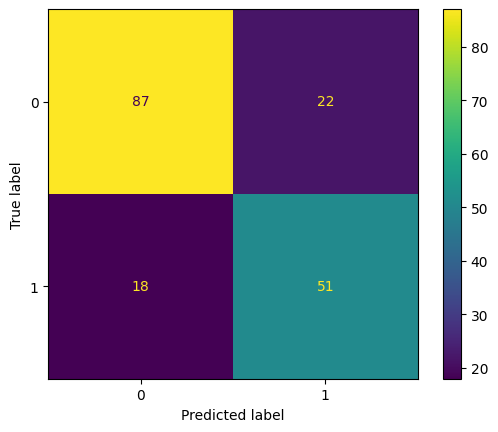

In [77]:
# Confusion Matrix
# Import confusion_matrix and ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use clf_knn to predict the labels of x_test and store it as predictions
predictions = clf_knn.predict(x_test)

# Generate a confusion matrix using y_test and predictions and store it as cm
cm = confusion_matrix(y_test, predictions)

# Plot the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()